# Машинное обучение, ФКН ВШЭ

## Практическое задание 4. Классификация

### Общая информация
Дата выдачи: 16.11.2024

Мягкий дедлайн: 28.11.2024

Жесткий дедлайн: 02.12.2024

### О задании

В этом задании вы:
- ознакомитесь с тем, что происходит "внутри" метода опорных векторов и логистической регрессии
- познакомитесь с калибровкой вероятности
- изучите методы трансформации переменных и методы отбора признаков
- попробуете оценить экономический эффект модели

----

#### Самостоятельная оценка результатов

Для удобства проверки, исходя из набора решенных задач, посчитайте свою максимальную оценку.

**Оценка**:

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

### Формат сдачи

Для сдачи задания переименуйте получившийся файл *.ipynb в соответствии со следующим форматом: homework-practice-04-linclass-__Username__.ipynb, где Username — ваша фамилия и имя на латинице именно в таком порядке (например, homework-practice-04-linclass-__IvanovIvan__.ipynb).

# Часть 1. SVM, LR и калибровка вероятностей (2 балла + 0.5 бонус)

In [1]:
import numpy as np
import pandas as pd
# import polars as pl
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
# pl.Config().set_tbl_rows(100)
# pl.Config().set_tbl_cols(100)

#### __Задание 1.1  Сравнение методов__ (0.5 балла)



Сгенерируем синтетические данные.

In [68]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# фиксируем random_state для воспроизводимости результатов
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

__Случайный классификатор__

Для начала зададим самую простую модель, которая на каждом объекте выдаёт случайный ответ. По тестовой выборке вычислим AUC-ROC, AUC-PR.

In [4]:
from sklearn.dummy import DummyClassifier
random_classifier = DummyClassifier(strategy='uniform', random_state=42).fit(X_train, y_train)
y_random = random_classifier.predict_proba(X_test)[:,1]
y_random

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5])

**Вопрос:** решаем задачу бинарной классификации, но y\_random содержит какие-то дробные числа, а не 0/1. Почему?



**Ответ**: Поскольку стратегия uniform используется, все вероятности равны 0.5, что означает, что модель считает, что каждый пример с равной вероятностью может принадлежать к классу 0 или классу 1.

*Ниже приведен **пример** работы* со встроенными функциями `sklearn` для отрисовки ROC и PR кривых, сохранения метрик. Пайплайн можно изменять как вам удобно.

In [6]:
from sklearn.metrics import average_precision_score

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

Random Classifier metrics
AUC-PR: 0.5057
AUC-ROC: 0.5000


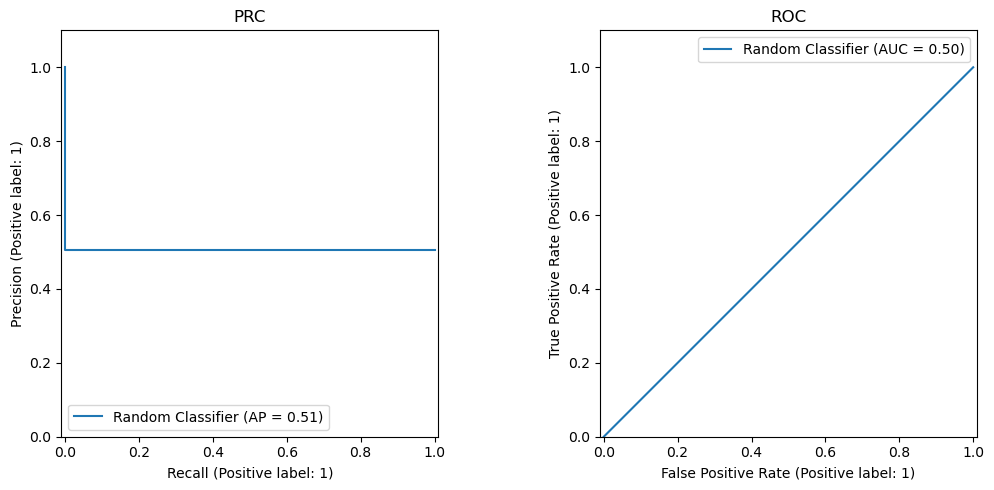

In [7]:
def depict_pr_roc(y_true, y_pred, classifier_name='Some Classifier', ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(11, 5))

    print(classifier_name, 'metrics')
    PrecisionRecallDisplay.from_predictions(y_true, y_pred, ax=ax[0], name=classifier_name)
    print('AUC-PR: %.4f' % average_precision_score(y_true, y_pred))
    ax[0].set_title("PRC")
    ax[0].set_ylim(0, 1.1)

    RocCurveDisplay.from_predictions(y_true, y_pred, ax=ax[1], name=classifier_name)
    print('AUC-ROC: %.4f' % roc_auc_score(y_true, y_pred))
    ax[1].set_title("ROC")
    ax[1].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.legend()


depict_pr_roc(y_test, y_random, 'Random Classifier')

In [38]:
# dataframe для сравнения
# методов классификации по метрикам
df_metrics = pd.DataFrame(
    columns=['auc_pr', 'roc_auc_score', 'reg_const']
)
precision, recall, _ = precision_recall_curve(y_test, y_random)
# добавление очередной строки с характеристиками метода
df_metrics.loc['Random Classifier'] = [
      average_precision_score(y_test, y_random),
      roc_auc_score(y_test, y_random),
      0,
]

# по аналогии результаты следующих экспериментов можно будет собрать в табличку
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.505667,0.5,0.0


__Support Vector Machine (Linear Kernel)__

Обучите метод опорных векторов.

Подберите параметр регуляризации `C` с точки зрения AUC-PR (можете воспользоваться кросс-валидацией или отделить валидационную выборку от обучающей).


In [52]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer
import warnings
from sklearn.exceptions import ConvergenceWarning

#warnings.filterwarnings('ignore', category=ConvergenceWarning)

param_grid = {'C': np.logspace(-5, 5, 10)}
linsvc_pr_scorer = make_scorer(average_precision_score)

grid_search = GridSearchCV(LinearSVC(dual=True, max_iter=5000), param_grid, scoring=linsvc_pr_scorer, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearSVC(dual=True, max_iter=5000),
             param_grid={'C': array([1.00000000e-05, 1.29154967e-04, 1.66810054e-03, 2.15443469e-02,
       2.78255940e-01, 3.59381366e+00, 4.64158883e+01, 5.99484250e+02,
       7.74263683e+03, 1.00000000e+05])},
             scoring=make_scorer(average_precision_score, response_method='predict'))

In [53]:
best_c = grid_search.best_params_
best_c

{'C': 0.0016681005372000592}

  На тестовой части:
  - постройте ROC и PR кривые,
  - посчитайте AUC-ROC, AUC-PR

In [54]:
best_model = grid_search.best_estimator_

y_predict = best_model.decision_function(X_test)

LinearSVC metrics
AUC-PR: 0.8297
AUC-ROC: 0.8475


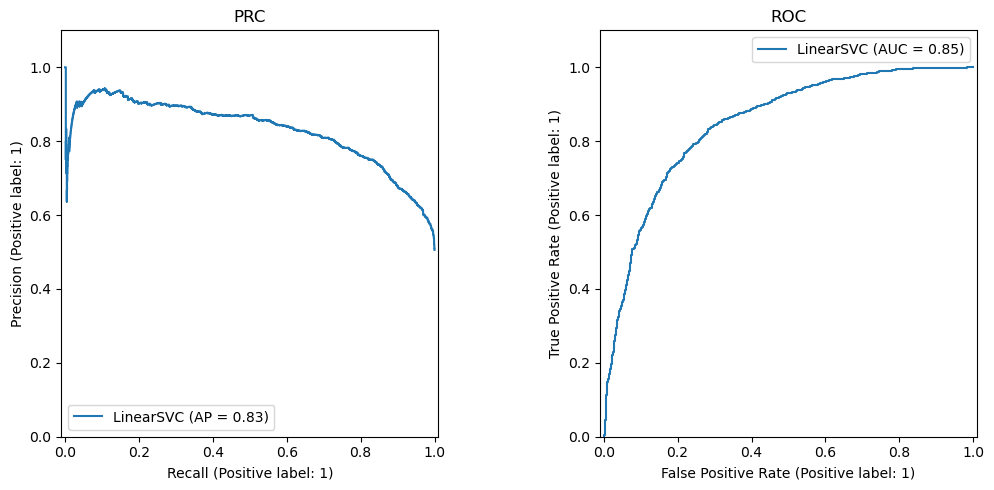

In [55]:
depict_pr_roc(y_test, y_predict, "LinearSVC")

Проанализируйте, как себя ведут обе кривые:
- Что происходит при увеличении порога? Как бы вы это проинтерпретировали?

PRC: При увеличении порога, precision увеличивается, так как модель становится более строгой в отношении того, что она считает положительным классом. Однако recall уменьшается, так как меньше положительных примеров правильно классифицируются.

ROC: При увеличении порога, TPR уменьшается, так как меньше положительных примеров правильно классифицируются, а FPR также уменьшается, так как меньше отрицательных примеров ошибочно классифицируются как положительные.

- Монотонные ли кривые? Как вы это объясните?

ROC: Mонотонно возрастает, так как TPR и FPR изменяются в одном направлении при изменении порога.

PRC: Не является монотонной, это связано с тем, что при изменении порога изменяются и precision, и recall, и их соотношение может варьироваться.

Сравните AUC-ROC и AUC-PR для вашей модели с этими же метриками для случайного классификатора.

In [56]:
precision, recall, _ = precision_recall_curve(y_test, y_predict)

df_metrics.loc['LinearSVC'] = [
      average_precision_score(y_test, y_predict),
      roc_auc_score(y_test, y_predict),
      best_c['C']
]

In [57]:
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.505667,0.500000,0.0
LinearSVC,0.829678,0.847527,0.001668


__Logistic Regression__


Аналогичное задание для логистической регрессии с L2 регуляризатором:


*   подберите гиперпараметр C, используя метрику AUC-PR
*   нарисуйте ROC, PR кривые для тестовой части
*   выведите метрики для тестовых данных и сравните их с результатами случайного классификатора



In [58]:
from sklearn.linear_model import LogisticRegression

param_grid_log = {'C': np.logspace(-5, 5, 10)}
linsvc_pr_scorer = make_scorer(average_precision_score)

grid_search = GridSearchCV(LogisticRegression(), param_grid, scoring=linsvc_pr_scorer, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-05, 1.29154967e-04, 1.66810054e-03, 2.15443469e-02,
       2.78255940e-01, 3.59381366e+00, 4.64158883e+01, 5.99484250e+02,
       7.74263683e+03, 1.00000000e+05])},
             scoring=make_scorer(average_precision_score, response_method='predict'))

In [59]:
best_c_log = grid_search.best_params_
best_c_log

{'C': 0.2782559402207126}

Нарисуйте ROC, PR кривые для тестовой части для всех 3 классификаторов на одном графике

In [71]:
best_model = LogisticRegression(C=best_c_log['C']).fit(X_train, y_train)
y_predict = best_model.decision_function(X_test)

LogisticRegression metrics
AUC-PR: 0.8294
AUC-ROC: 0.8479


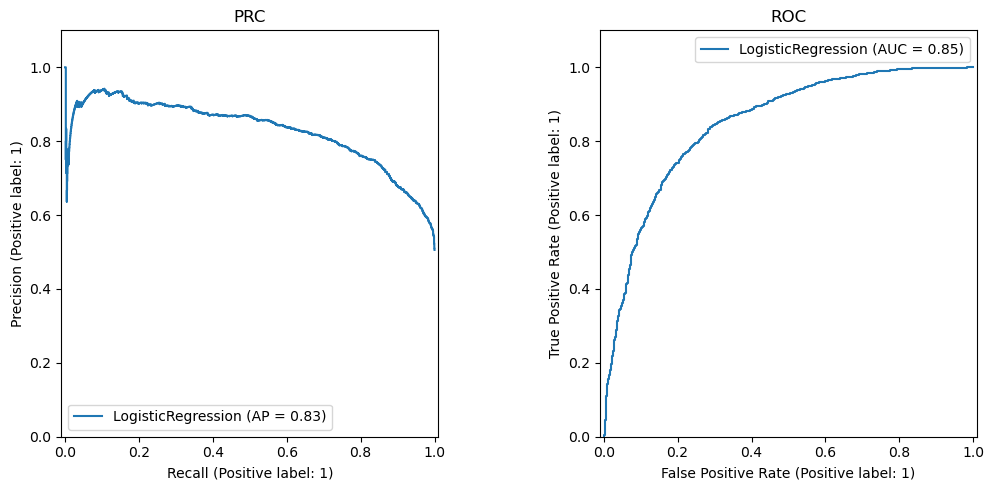

In [72]:
depict_pr_roc(y_test, y_predict, "LogisticRegression")

In [73]:
precision, recall, _ = precision_recall_curve(y_test, y_predict)

df_metrics.loc['LogisticRegression'] = [
      average_precision_score(y_test, y_predict),
      roc_auc_score(y_test, y_predict),
      best_c_log['C']
]

In [74]:
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.505667,0.500000,0.0
LinearSVC,0.829678,0.847527,0.001668
LogisticRegression,0.829404,0.847872,0.278256


**Вопрос:** Сравните результаты LR и SVM с точки зрения всех вычисленных критериев качества, объясните различия (если они есть).



**Ответ:** различия почти нет, и то и то справляется хорошо

#### __Задание 1.2. Визуализация в подходах SVM, LR__ (0.5 балла)



В названии метода опорных векторов присутствуют некоторые "опорные векторы". По сути, это объекты из обучающей выборки, которые задали положение разделяющей гиперплоскости.

* Сгенерируйте синтетические данные с помощью `make_classification` __с 2 признаками__, обучите на нём метод опорных векторов. Не забудьте зафиксировать seed для воспроизводимости

* Визуализируйте разделяющую прямую, все объекты и выделите опорные векторы. Ниже есть шаблоны, можете воспользоваться ими, либо написать своё

In [122]:
X, y = make_classification(
    n_samples=10000, n_features=2, n_informative=2, n_redundant=0, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [123]:
from sklearn.svm import SVC
model = SVC(kernel='linear', C=best_c['C']).fit(X_train, y_train)

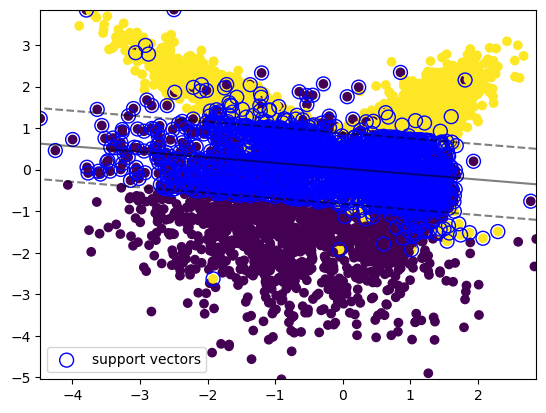

In [124]:
def plot_svm_2D(X, y, model,  plot_support=True):

    # создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Ответы модели для сетки для отрисовки разделяющей прямой
    Z = model.decision_function(xy).reshape(XX.shape)

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Отрисовали выборку
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y
    )

    # Отрисовали опорные векторы
    if plot_support:
        plt.scatter(
            model.support_vectors_[:, 0], 
            model.support_vectors_[:, 1],
            label='support vectors',
            s=100,
            linewidth=1,
            edgecolor="blue",
            facecolors='none'
        )

    plt.legend()

plot_svm_2D(X_train, y_train, model)

**Вопрос:** какие объекты выделяются как "опорные"?



**Ответ:** Опорные объекты - это те объекты, которые ближе к гиперплоскости.

В отличие от метода опорных векторов, логистическая регрессия не пытается построить разделяющую гиперплоскость с максимальным отступом, а приближает в каждой точке пространства объектов вероятность положительных ответов $p(y=+1|x)$. Попробуйте нарисовать это распределение на плоскости, не забудьте отметить на ней все объекты.

In [89]:
model = LogisticRegression(C=best_c_log['C']).fit(X_train, y_train)

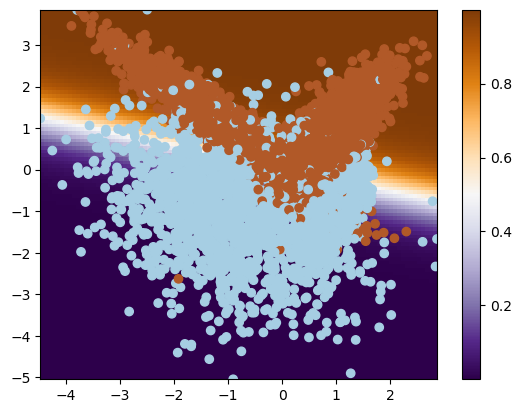

In [90]:
def plot_logreg_2D(X, y, model):

    # создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Ответы модели для сетки для отрисовки распределения
    Z = model.predict_proba(xy)[:,1]
    Z = Z.reshape((xx.shape[0], -1)).T

    image = plt.imshow(
        Z,
        interpolation='nearest',
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        aspect='auto',
        origin='lower',
        cmap=plt.cm.PuOr_r
    )

    #Отрисовали выборку
    plt.scatter(
         X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.Paired
    )

    plt.colorbar(image)

plot_logreg_2D(X_train, y_train, model)

**Вопрос:** Как на картинке визуализирована область, где модель не уверена ($p(y=+1|x) = 0.5$)? Как это обосновать теоритечески?



**Ответ:** Белая линия. Это значит, что модель выдает около 0.5 и не уверен в классификации.

#### __Задание 2. Калибровка вероятностей__ (1 балл)



Перейдём к оценке качества выдаваемых алгоритмами вероятностей. Начнём с калибровочных кривых.

Допустим, алгоритм возвращает некоторые числа от нуля до единицы. Хорошо ли они оценивают вероятность?

Хорошо откалиброванный  классификатор должен выдавать значения так, чтобы среди образцов, для которых он дал значение, близкое к $\alpha$, примерно $\alpha * 100 \%$ фактически принадлежали к положительному классу. (Например, если классификатор выдает 0.3 для некоторых, то 30% из них должны принадлежать классу 1)

Для построения калибровочной криовой используем следующий алгоритм:

Разобьем отрезок $[0, 1]$ на несколько маленьких отрезков одинаковой длины.

Рассмотрим $i$-й отрезок с границами $[a_i, b_i]$ и предсказания $p_1, p_2, \dots, p_k$, которые попали в него. Пусть им соответствуют истинные ответы $y_1, y_2, \dots, y_k$. Если алгоритм выдает корректные вероятности, то среди этих истинных ответов должно быть примерно $(a_i + b_i) / 2$ единиц. Иными словами, если нарисовать кривую, у которой по оси X отложены центры отрезков, а по оси Y — доли единичных ответов этих в отрезках, то она должна оказаться диагональной.

Ниже приведена функция, которая должна рисовать такие кривые. В ней допущено две ошибки — найдите и исправьте их.

In [109]:
def plot_calibration_curve(y_test, preds):
    bin_middle_points = []
    bin_real_ratios = []
    n_bins = 10
    for i in range(n_bins):
        l = 1.0 / n_bins * i
        r = 1.0 / n_bins * (i + 1)
        bin_middle_points.append((l + r) / 2)
        bin_real_ratios.append(np.mean(y_test[(preds >= l) & (preds < r)] == 1))
    #plt.figure(figsize=(6,6))
    #print(bin_middle_points)
    plt.plot(bin_middle_points, bin_real_ratios)
    plt.ylim([-0.05, 1.05])
    plt.grid()

Сгенерируйте синтетические данные аналогично использованным в самом первом задании. Постройте калибровочные кривые на тестовой части для логистической регрессии и метода опорных векторов (не забудьте перевести его предсказания в $[0;1]$).

Отрисуйте калибровочную кривую идеально откалиброванной модели (диагональ)

In [138]:
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

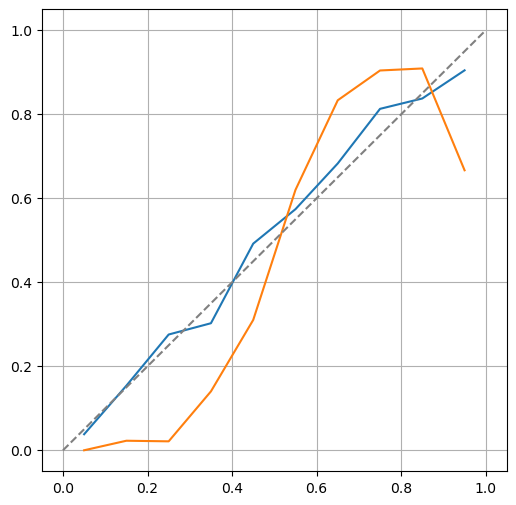

In [128]:
from sklearn.preprocessing import minmax_scale

plt.figure(figsize=(6,6))

y_pred_lr = LogisticRegression(C=best_c_log['C']).fit(X_train, y_train).predict_proba(X_test)
plot_calibration_curve(y_test, y_pred_lr[:, 1])

y_pred_svm_before = LinearSVC(dual=True, C=best_c['C']).fit(X_train, y_train).decision_function(X_test)
y_pred_svm = minmax_scale(y_pred_svm_before)
plot_calibration_curve(y_test, y_pred_svm)

plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated', color='gray')
plt.ylim([-0.05, 1.05])
plt.grid()
plt.show()

**Вопрос**: хорошо ли откалиброваны кривые для SVM, логистической регрессии? Подумайте, как это следует из вида кривой

**Ответ:** У logreg получился отличный кривой - почти на равне с идеальной кривой. SVM колебается сильнее чем logreg.

Из формальных способов в этом убедиться есть знакомый вам LogLoss, который напрямую оценивает вероятности,
$$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0. 1}}\log p_k[y_i = k]$$
а так же BrierScore, который подсчитывает отклонение между получившейся вероятностью и реальным значением таргета.
$$\text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2$$
Посмотрите на них тоже и сделайте вывод

In [131]:
from sklearn.metrics import log_loss, brier_score_loss

log_loss_log_reg = log_loss(y_test, y_pred_lr[:, 1])
log_loss_svm = log_loss(y_test, y_pred_svm)

brier_score_log_reg = brier_score_loss(y_test, y_pred_lr[:, 1])
brier_score_svm = brier_score_loss(y_test, y_pred_svm)

print(f"Log Loss (Logistic Regression): {log_loss_log_reg:.4f}")
print(f"Log Loss (SVM): {log_loss_svm:.4f}")
print(f"Brier Score (Logistic Regression): {brier_score_log_reg:.4f}")
print(f"Brier Score (SVM): {brier_score_svm:.4f}")

Log Loss (Logistic Regression): 0.4859
Log Loss (SVM): 0.5549
Brier Score (Logistic Regression): 0.1586
Brier Score (SVM): 0.1846


Обе модели получили неплохую оценку, но Logres немного лучше.

Изучите распределение ответов классификаторов при помощи гистограмм

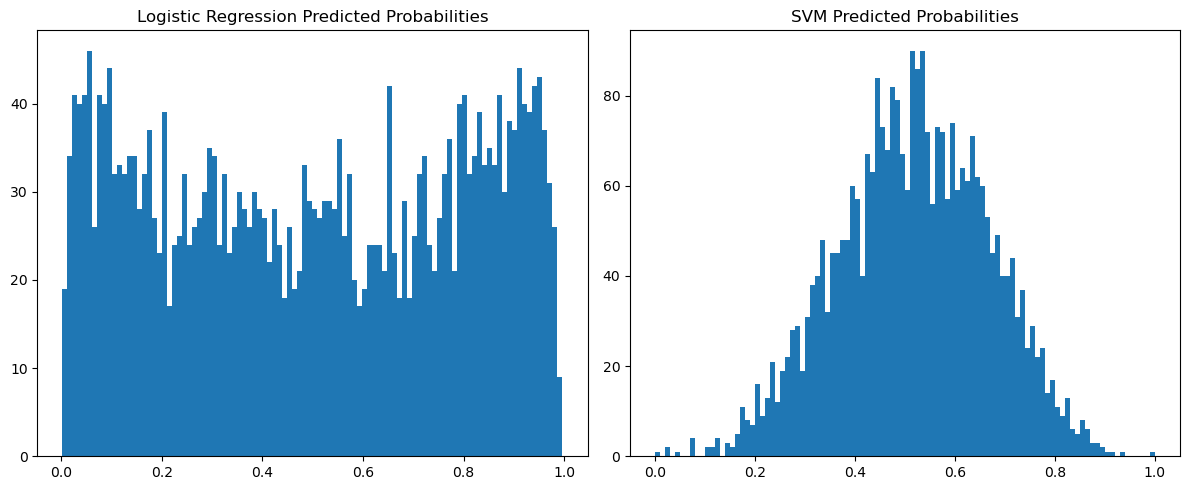

In [133]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(y_pred_lr[:, 1], bins=100)
plt.title('Logistic Regression Predicted Probabilities')

plt.subplot(1, 2, 2)
plt.hist(y_pred_svm, bins=100)
plt.title('SVM Predicted Probabilities')

plt.tight_layout()
plt.show()

**Вопрос:** Чем они различаются? Чем вы можете объяснить это?

**Ответ:** Logress дает более уверенные предсказания, а SVM плохо предсказывает(большая часть получила 0.5). Логрес это ммп для Бернулли, а svm более фокусирован на расстояние между классами.

Воспользуйтесь `CalibratedClassifierCV` из `sklearn` для калибровки вероятностей метода опорных векторов на обучении и постройте с его помощью  предсказания для тестовой выборки.

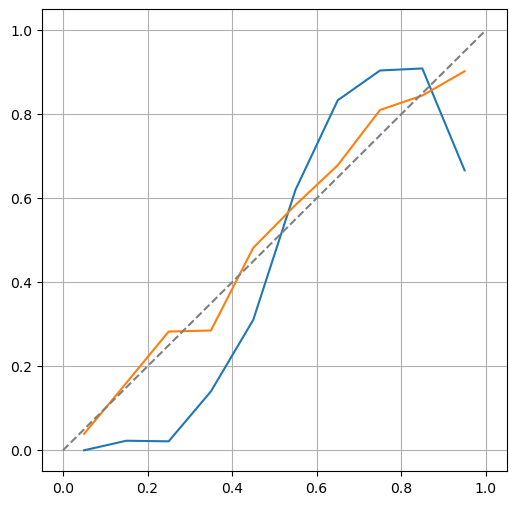

In [135]:
from sklearn.preprocessing import minmax_scale
from sklearn.calibration import CalibratedClassifierCV

plt.figure(figsize=(6,6))

y_pred_svm_before = LinearSVC(dual=True, C=best_c['C']).fit(X_train, y_train).decision_function(X_test)
y_pred_svm = minmax_scale(y_pred_svm_before)
plot_calibration_curve(y_test, y_pred_svm)

y_pred_cccv = CalibratedClassifierCV(estimator=LinearSVC(dual=True, C=best_c['C'])).fit(X_train, y_train).predict_proba(X_test)
plot_calibration_curve(y_test, y_pred_cccv[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated', color='gray')
plt.ylim([-0.05, 1.05])
plt.grid()
plt.show()

**Вопрос:** Улучшились ли калибровочная кривая и качество калибровки?

**Ответ:** Стало на много лучше

##### __Бонус: Авторское решение__ (0.5 балла)

Реализуйте свою функцию для калибровки вероятностей, используя любой из известных подходов. Кратко опишите ваш подход и продемонстрируйте результаты. Ключевые слова для вдохновения: `Platt`, `Isotonic`.

In [143]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss

class PlattCalibrator:
    def __init__(self):
        self.lr = LogisticRegression()

    def fit(self, scores, y):
        scores = scores.reshape(-1, 1)
        self.lr.fit(scores, y)
        return self

    def predict_proba(self, scores):
        scores = scores.reshape(-1, 1)
        return self.lr.predict_proba(scores)[:, 1]

scores = SVC(kernel='linear', probability=True, C=best_c['C']).fit(X_train, y_train).decision_function(X_train)

platt_calibrator = PlattCalibrator().fit(scores, y_train)

test_scores = svm.decision_function(X_test)
prob_pos_platt = platt_calibrator.predict_proba(test_scores)

print("Brier score loss (Platt Calibrated SVM):", brier_score_loss(y_test, prob_pos_platt))
print("Log loss (Platt Calibrated SVM):", log_loss(y_test, prob_pos_platt))

Brier score loss (Platt Calibrated SVM): 0.15844868364634088
Log loss (Platt Calibrated SVM): 0.48721746487131956


# Часть 2. Обработка категориальных переменных (4 балла + 1.5 бонус)

Как мы знаем, перекодировать категориальную переменную в список чисел (к примеру 1, 2, 3, ..., n) плохо, поскольку это бы задало на множестве ее значений некоторый порядок, не имеющий смысла.

В этой части мы рассмотрим два основных способа обработки категориальных значений:
- One-hot-кодирование
- Счётчики (CTR, mean-target кодирование, ...) — каждый категориальный признак заменяется на среднее значение целевой переменной по всем объектам, имеющим одинаковое значение в этом признаке.

Начнём с one-hot-кодирования. Допустим наш категориальный признак $f_j(x)$ принимает значения из множества $C=\{c_1, \dots, c_m\}$. Заменим его на $m$ бинарных признаков $b_1(x), \dots, b_m(x)$, каждый из которых является индикатором одного из возможных категориальных значений:
$$
b_i(x) = [f_j(x) = c_i]
$$

#### __Подготовка данных__

*(бесценный шаг)*

Разберем датасет [покупок велосипедов](https://www.kaggle.com/datasets/heeraldedhia/bike-buyers/): даны признаки покупателя, требуется предсказать, купит ли он/она велосипед



Замените пропуски в категориальных переменных на новую категорию (`'undefined'`)

Разделите признаки на 2 таблицы: категориальные и числовые признаки

In [282]:
df = pd.read_csv('bike_buyers.csv.xls')
df.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


In [283]:
df.drop('ID', axis=1, inplace=True)

X = df.drop(columns=['Purchased Bike'])
y = (df['Purchased Bike'] == 'Yes').astype('int64')

X_numerical = df[list(X.select_dtypes([np.number]).columns)].fillna(0)
X_categorical = df[list(X.dtypes[X.dtypes == "object"].index)].fillna('undefined')

В начале поработаем только с категориальными признаками

In [169]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_categorical, y, test_size=0.25, random_state=777, stratify=y)

#### __Задание 3. OrdinalEncoder__  (0.5 балла)

Закодируйте категориальные признаки с помощью `OrdinalEncoder`. Посчитайте качество (в этом задании будем работать c __`AUC-PR`__) при применении логистической регрессии. Замерьте время, потребовавшееся на обучение модели, с учетом кодирования признаков.

In [210]:
from sklearn.preprocessing import OrdinalEncoder
import time

begin = time.time()

encoder = OrdinalEncoder()
X_train_oe = encoder.fit_transform(X_train)
X_test_oe = encoder.transform(X_test)

model = LogisticRegression()
model.fit(X_train_oe, y_train)
print("time:", time.time() - begin)

y_pred = model.predict_proba(X_test_oe)[:, 1]
print("AUC-PR:", average_precision_score(y_test, y_pred))

time: 0.015326976776123047
AUC-PR: 0.5886533539773633


#### __Задание 4. One-Hot Encoding__ (0.5 балла)



Закодируйте все категориальные признаки с помощью one-hot-кодирования. Обучите логистическую регрессию и посмотрите, как изменилось качество модели (в сравнении с тем, что было до кодирования). Измерьте время, потребовавшееся на кодирование категориальных признаков и обучение модели.

In [207]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import time

begin = time.time()

encoder = OneHotEncoder()
X_train_oe = encoder.fit_transform(X_train)
X_test_oe = encoder.transform(X_test)

model = LogisticRegression()
model.fit(X_train_oe, y_train)
print("time:", time.time() - begin)

y_pred = model.predict_proba(X_test_oe)[:, 1]
print("AUC-PR:", average_precision_score(y_test, y_pred))

time: 0.018777847290039062
AUC-PR: 0.6662544177340515


Как можно заметить, one-hot-кодирование может сильно увеличивать количество признаков. Это сказывается на объеме необходимой памяти, особенно, если некоторый признак имеет большое количество значений.


#### __Задание 5. Mean-target Encoding__ (1 балл)

> Проблемы разрастания числа признаков можно избежать в другом способе кодирования категориальных признаков — mean-target encoding (для простоты будем называть это __счётчиками__). Сравним эффективность методов в рамках нашей маркетинговой задачи.

> Основная идея в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$

Закодируйте категориальные переменные с помощью счётчиков (ровно так, как описано выше, без каких-либо хитростей). Обучите логистическую регрессию и посмотрите на качество модели на тестовом множестве.

Сравните время обучения с предыдущими экспериментами (с учетом кодирования признаков).

In [200]:
begin = time.time()

X_train_mean = X_train.copy()
X_test_mean = X_test.copy()

train_xy = pd.concat([X_train_mean, y_train], axis=1)

for col in X_train_mean.columns:
    means = train_xy.groupby(col)['Purchased Bike'].mean()
    X_train_mean[col] = X_train_mean[col].map(means)
    X_test_mean[col] = X_test_mean[col].map(means)

X_train_mean = X_train_mean.astype('float64')
X_test_mean = X_test_mean.astype('float64')

model = LogisticRegression()
model.fit(X_train_mean, y_train)
print("time:", time.time() - begin)

y_pred = model.predict_proba(X_test_mean)[:, 1]
print("AUC-PR:", average_precision_score(y_test, y_pred))

time: 0.019247055053710938
AUC-PR: 0.6575110261581697


Время обучения и качество модели почти такой же.

##### __Бонус: Эффективная реализация (1 балл)__

Здесь и далее реализуйте вычисление счетчиков с помощью трансформера (наследуйтесь от классов `BaseEstimator, TransformerMixin` из `sklearn.base`). Обратите внимание, что все вычисления должны быть векторизованными, трансформер не должен модифицировать передаваемую ему выборку inplace, а все необходимые статистики нужно считать только по обучающей выборке в методе `fit`. Ваш трансформер должен принимать при инициализации список из категориальных признаков и изменять только их.

In [219]:
from sklearn.base import BaseEstimator, TransformerMixin

class MeanTarget_Encoding(BaseEstimator, TransformerMixin):
    def __init__(self, features, target='Purchased Bike', noise = None):
        self.features = features
        self.means = {}
        self.target = target
        self.noise = noise
    
    def fit(self, X_train, y_train):
        train_xy = pd.concat([X_train, y_train], axis=1)

        for col in self.features:
            self.means[col] = train_xy.groupby(col)[self.target].mean()
        
        return self
    
    def transform(self, X):
        new_X = X.copy()
        
        for col in self.features:
            new_X[col] = new_X[col].map(self.means[col])
            
            if self.noise is not None:
                new_X[col] += np.random.normal(0, self.noise, new_X[col].shape)
        
        new_X = new_X.astype('float64')
        
        return new_X

In [220]:
begin = time.time()

trans = MeanTarget_Encoding(X_train.columns)
X_train_mean = trans.fit_transform(X_train, y_train)
X_test_mean = trans.transform(X_test)

model = LogisticRegression()
model.fit(X_train_mean, y_train)
print("time:", time.time() - begin)

y_pred = model.predict_proba(X_test_mean)[:, 1]
print("AUC-PR:", average_precision_score(y_test, y_pred))


time: 0.021185874938964844
AUC-PR: 0.6575110261581697


_______

__Методы борьбы с переобучением счетчиков__


Отметим, что mean-target encoding признаки сами по себе являются классификаторами и, обучаясь на них, мы допускаем "утечку" целевой переменной в признаки. Это ведёт к __переобучению__, поэтому считать такие признаки необходимо таким образом, чтобы при вычислении для конкретного объекта его __целевая метка не использовалась__.

Это можно делать следующими способами:
1. Вычислять значение счётчика по всем объектам расположенным выше в датасете (например, если у нас выборка отсортирована по времени).
2. Вычислять по фолдам, то есть делить выборку на некоторое количество частей и подсчитывать значение признаков по всем фолдам кроме текущего (как делается в кросс-валидации).
3. Внесение некоторого шума в посчитанные признаки.

#### __Задание 6. Пошумим__  (0.5 балла)

Реализуйте корректное вычисление счётчиков самым простым способом — добавление шума к значениям.  При этом постарайтесь найти баланс между борьбой с переобучением и сохранением полезности признаков. Снова обучите логистическую регрессию, оцените качество.

In [230]:
begin = time.time()

trans = MeanTarget_Encoding(X_train.columns, noise=10)
X_train_mean = trans.fit_transform(X_train, y_train)
X_test_mean = trans.transform(X_test)

model = LogisticRegression()
model.fit(X_train_mean, y_train)
print("time:", time.time() - begin)

y_pred = model.predict_proba(X_test_mean)[:, 1]
print("AUC-PR:", average_precision_score(y_test, y_pred))


time: 0.02045416831970215
AUC-PR: 0.44643090012711223


**Вопрос:** Сделайте выводы. Помогло ли добавление шума? Почему?

**Ответ:** Не помогло, так как мы слишком много фокусируем на целеой переменной, а их значения только 0 или 1.

##### __Бонус: другой подход__ (0.5 балла)

Посчитайте корректные счётчики первым или вторым способов из описанных выше (не забудьте добавить и шум).




In [256]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold

class MeanTargetEncoderCV:
    def __init__(self, cat_features, n_splits=5, noise=0.1):
        self.cat_features = cat_features
        self.n_splits = n_splits
        self.noise = noise

    def fit_transform(self, X, y):
        X_encoded = X.copy()
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            for col in self.cat_features:
                train_data = X_train.copy()
                train_data['target'] = y_train.values

                means = train_data.groupby(col)['target'].mean()

                X_val.loc[:, col] = X_val[col].map(means)
                global_mean = y_train.mean()
                
                X_val.loc[:, col] = X_val[col].astype('float64')

                noise_array = np.random.normal(0, self.noise, X_val[col].shape)
                X_val.loc[:, col] += noise_array

            X_encoded.iloc[val_idx] = X_val

        return X_encoded

    
encoder = MeanTargetEncoderCV(cat_features=X_train.columns, n_splits=10, noise=15)
X_train_mean = encoder.fit_transform(X_train, y_train)

begin = time.time()

model = LogisticRegression()
model.fit(X_train_mean, y_train)
print("time:", time.time() - begin)

y_pred = model.predict_proba(X_test_mean)[:, 1]
print("AUC-PR:", average_precision_score(y_test, y_pred))

time: 0.0018529891967773438
AUC-PR: 0.5313221953774792


#### __Задание 7. Сглаживание счетчиков__  (1 балл)

> Теперь ответим на следующий вопрос: что будет, если некоторая категория встречается в выборке всего несколько раз? По этой причине производится сглаживание счётчиков. Например, на практике хорошие результаты показывает использование сглаживания средним по всей выборке:
$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1] + C \times \text{global_mean}}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)] + C}
$$
где $\text{global_mean}$ — доля объектов положительного класса в выборке, $C$ — параметр, определяющий степень сглаживания (можно использовать 10 или подобрать для каждого признака свой). Идея в том, что мы "разбавляем" среднее значение по категории глобальным средним значением. И тем меньше, чем большее количество объектов этой категории встречается в выборке.

> Вместо среднего значения целевой переменной для сглаживания можно использовать любое другое значение от 0 до 1 (этот параметр иногда называют $prior$). Можно сделать несколько признаков с разными значениями параметра. На практике в задачах бинарной классификации полезными бывают даже отрицательные значения!

Добавьте сглаживание, описанное выше и повторите эксперименты. Подберите $C$, чтобы качество было лучше, чем при использовании One-Hot-Encoding


In [257]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_categorical, y, test_size=0.25, random_state=777, stratify=y)

In [261]:
from sklearn.base import BaseEstimator, TransformerMixin

class MeanTarget_Encoding(BaseEstimator, TransformerMixin):
    def __init__(self, features, target='Purchased Bike', C=5):
        self.features = features
        self.means = {}
        self.target = target
        self.C = C
    
    def fit(self, X_train, y_train):
        train_xy = pd.concat([X_train, y_train], axis=1)

        for col in self.features:
            up = train_xy.groupby(col)[self.target].sum() + self.C * np.mean(y_train)
            down = train_xy.groupby(col)[self.target].size() + self.C
            self.means[col] = up / down
        
        return self
    
    def transform(self, X):
        new_X = X.copy()
        
        for col in self.features:
            new_X[col] = new_X[col].map(self.means[col])
        
        new_X = new_X.astype('float64')
        
        return new_X

In [279]:
find_best_c = {}

for C in range(0, 100):
    
    begin = time.time()

    trans = MeanTarget_Encoding(X_train.columns, C=C)
    X_train_mean = trans.fit_transform(X_train, y_train)
    X_test_mean = trans.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train_mean, y_train)
    
    y_pred = model.predict_proba(X_test_mean)[:, 1]
    score_ = average_precision_score(y_test, y_pred)
    find_best_c[score_] = C
    #print(score_)

best_C_mte = find_best_c[max(find_best_c.keys())]
best_C_mte

9

In [280]:
begin = time.time()

trans = MeanTarget_Encoding(X_train.columns, C=best_C_mte)
X_train_mean = trans.fit_transform(X_train, y_train)
X_test_mean = trans.transform(X_test)

model = LogisticRegression()
model.fit(X_train_mean, y_train)
print("time:", time.time() - begin)

y_pred = model.predict_proba(X_test_mean)[:, 1]
print("AUC-PR:", average_precision_score(y_test, y_pred))

time: 0.022943973541259766
AUC-PR: 0.67256590814385


#### **Задание 8. Числовые или категориальные?**  (0.5 балла)

Теперь добавим числовые признаки к счётчикам (тем, которые дали наибольший прирост качества).


Проверьте их на наличие выбросов и заполните пропуски средним или медианой, подумайте, что лучше в условиях наших данных



In [344]:
new_df = pd.read_csv('bike_buyers.csv.xls')

new_df.drop('ID', axis=1, inplace=True)

X = new_df.drop(columns=['Purchased Bike'])
y = (new_df['Purchased Bike'] == 'Yes').astype('int64')

X_numerical = new_df[list(X.select_dtypes([np.number]).columns)].apply(lambda col: col.fillna(col.mean()), axis=0)
X_categorical = new_df[list(X.dtypes[X.dtypes == "object"].index)].fillna('undefined')

In [345]:
full = pd.concat((X_categorical, X_numerical), axis=1)
X_train, X_test, y_train, y_test = train_test_split(full, y, test_size=0.25, random_state=777, stratify=y)

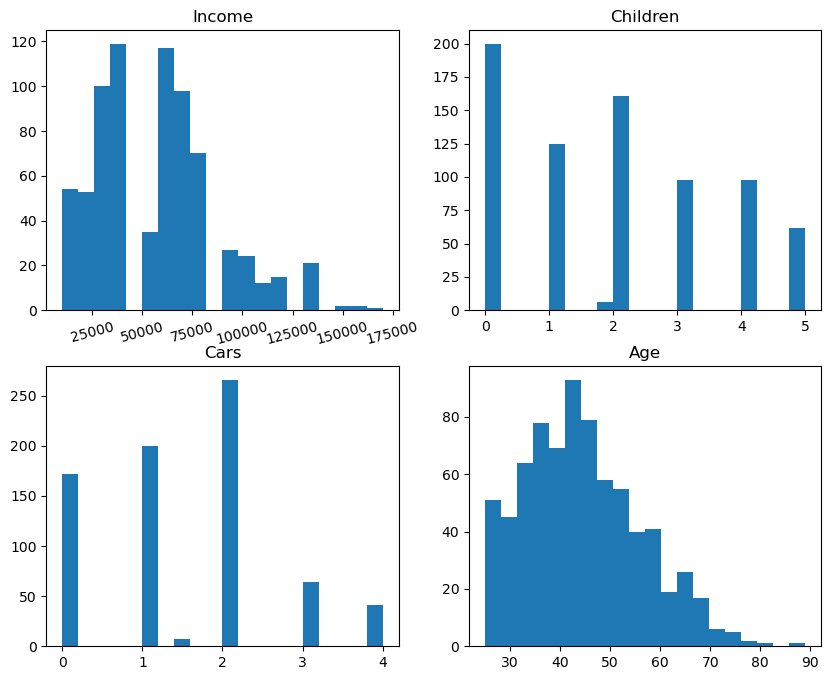

In [346]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.hist(X_train['Income'], bins=20)
plt.title('Income')
plt.xticks(rotation=15)

plt.subplot(2, 2, 2)
plt.hist(X_train['Children'], bins=20)
plt.title('Children')

plt.subplot(2, 2, 3)
plt.hist(X_train['Cars'], bins=20)
plt.title('Cars')

plt.subplot(2, 2, 4)
plt.hist(X_train['Age'], bins=20)
plt.title('Age')

plt.show()

In [347]:
new_Xy = pd.concat((X_train, y_train), axis=1)
new_Xy = new_Xy[(20 < new_Xy['Age']) & (new_Xy['Age'] < 70) & (10000 <= new_Xy['Income']) & (new_Xy['Income'] <= 137500)]

In [348]:
X_train = new_Xy.drop(columns=['Purchased Bike'])
y_train = new_Xy['Purchased Bike']

 Сейчас для числовых признаков мы ищем линейную зависимость, что в общем случае  может быть неверной гипотезой. Тем не менее, у этих признаков есть довольно много уникальных значений (сколько?), поэтому применять к ним one-hot кодирование может оказаться излишним. Попробуйте закодировать эти признаки с помощью счетчиков. Стало ли лучше?

In [350]:
X_train['Income'].nunique(), X_train['Age'].nunique(), X_train['Cars'].nunique(), X_train['Children'].nunique()

(14, 46, 6, 7)

In [352]:
begin = time.time()

trans = MeanTarget_Encoding(X_train.columns, C=best_C_mte)
X_train_mean = trans.fit_transform(X_train, y_train)
X_test_mean = trans.transform(X_test).fillna(0)

model = LogisticRegression()
model.fit(X_train_mean, y_train)
print("time:", time.time() - begin)

y_pred = model.predict_proba(X_test_mean)[:, 1]
print("AUC-PR:", average_precision_score(y_test, y_pred))

time: 0.02401280403137207
AUC-PR: 0.6661729439877389


> __Замечание.__ Усложнение методов вычисления счётчиков не делают результаты модели гарантированно лучше. Особенно с учётом того, что логистическая регрессия не такая сложная модель, чтобы переобучаться. Поэтому вы необязательно должны были получать на каждом шаге всё лучшие и лучшие результаты (но необходимые результаты у вас должны были получиться).



Как мы могли пронаблюдать, счётчики являются конкурентной альтернативой one-hot-кодированию. Опишите, какие плюсы и минусы использования счётчиков по сравнению с one-hot-кодированием вы заметили.

__Ответ:__

Плюсы: Тратит меньше памяи и получает более хорошую оценку

Минусы: Фокусируем только на целевую переменную

# Часть 3. Отбор признаков (2 балла)

Загрузим данные [UCI Adult Dataset](https://archive.ics.uci.edu/ml/datasets/Adult). Этот набор данных содержит информацию о годовых доходах отдельных людей. В качестве признакового описания используется различная информация о человеке (образование, профессия, брачный статус и т.д.). Целевая переменная является бинарной: больше ли годовой доход 50K долларов или нет.

In [357]:
#!curl -O https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3881k    0 3881k    0     0   120k      0 --:--:--  0:00:32 --:--:--  236k   0     0  87571      0 --:--:--  0:00:02 --:--:-- 87568


In [358]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
    'income'
]

df = pd.read_csv('adult.data', header=None, names=columns)
df['income'] = (df['income'] != " <=50K").astype('int32')
df.sample()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
11092,40,Private,277647,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,1


Важной частью процесса построения модели является отбор признаков. На практике многие признаки оказывают малое влияние на модель (при этом их расчёт занимает время) или даже негативно сказываются на качестве модели. Попробуем несколько подходов отбора признаков, оценим, как они влияют на качество модели и сколько времени занимают.



Разделите выборку на обучающую и тестовую в соотношении 3:1. Зафиксируйте `random_state=777`, также используйте `stratify=True`.

In [359]:
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=777, stratify=y)

In [362]:
X_numerical = list(X.select_dtypes([np.number]).columns)
X_categorical = list(X.dtypes[X.dtypes == "object"].index)

Давайте закодируем все категориальные признаки с помощью One-hot Encoding. Сколько новых признаков мы получим?

In [364]:
X_train[X_categorical].shape

(24420, 8)

In [371]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import time

encoder = OneHotEncoder(sparse_output=False)
X_train_oe = encoder.fit_transform(X_train[X_categorical])
X_test_oe = encoder.transform(X_test[X_categorical])
X_train_oe.shape

(24420, 102)

В качестве основной модели будем использовать логистическую регрессию, а целевой метрики — `AUC-PR`. Обучите модель и посчитайте качество на тестовой выборке. Давайте запомним полученное значение.

In [376]:
X_train_oe_df = pd.DataFrame(X_train_oe, index=X_train.index)
X_test_oe_df = pd.DataFrame(X_test_oe, index=X_test.index)

X_train_oe_df.columns = X_train_oe_df.columns.astype(str)
X_test_oe_df.columns = X_test_oe_df.columns.astype(str)
X_train[X_numerical].columns = X_train[X_numerical].columns.astype(str)
X_test[X_numerical].columns = X_test[X_numerical].columns.astype(str)

X_train_combined = pd.concat([X_train_oe_df, X_train[X_numerical]], axis=1)
X_test_combined = pd.concat([X_test_oe_df, X_test[X_numerical]], axis=1)

model = LogisticRegression()
model.fit(X_train_combined, y_train)

y_pred = model.predict_proba(X_test_combined)[:, 1]

print("AUC-PR:", average_precision_score(y_test, y_pred))

AUC-PR: 0.45599741769247215


Допустим, мы хотим оставить только 40 лучших признаков.

Заметим, что нельзя оценивать качество по тестовой выборке, иначе мы можем переобучиться, как, например, при настройке гиперпараметров. Разделите обучающую выборку на 2 части, одну из которых, используйте для валидации. Исходную тестовую выборку стоит использовать только для финальной оценки качества после процедуры фильтрации

In [501]:
X_train_small, X_val, y_train_small, y_val = train_test_split(X_train_combined, y_train, test_size=0.25, random_state=777, stratify=y_train)

Попробуем сделать это следующими способами:

#### __Задание 9. Встроенные методы (0.5 балла)__

Начнём с отбора признаков с помощью модели. У разных алгоритмов есть разные встроенные способы оценки вклада признаков в предсказание. Как известно, у линейной модели за это отвечают веса, а значит, их модуль можно интерпретировать как важность. Такой метод отбора называются встроенным или embedded method, так как он заложен в особенности модели.

Оставьте 40 признаков с наибольшим модулем соответствующего параметра линейной модели. Обучите модели заново и оцените её качество. Замерьте скорость такого отбора признаков.



In [383]:
model = LogisticRegression()
model.fit(X_train_small, y_train_small)

y_pred = model.predict_proba(X_val)[:, 1]

print("AUC-PR:", average_precision_score(y_val, y_pred))

AUC-PR: 0.46764475082421864


In [385]:
begin = time.time()

feature_importance = np.abs(model.coef_[0])
top_features_indices = np.argsort(feature_importance)[-40:]

X_train_selected = X_train_small.iloc[:, top_features_indices]
X_test_selected = X_val.iloc[:, top_features_indices]

model_select = LogisticRegression()
model_select.fit(X_train_selected, y_train_small)

print("time:", time.time() - begin)
y_pred = model_select.predict_proba(X_test_selected)[:, 1]

print("AUC-PR:", average_precision_score(y_val, y_pred))

time: 0.13298296928405762
AUC-PR: 0.6862164099113066


Изменилось ли качество? Как?

Стало лучше

Подумаем, что мы не учли. Мы действовали в предположении, что признаки вносят вклад равномерно, и не учитывали их масштаб. Если мы умножим один из признаков в 100 раз, то без учёта регуляризации его вес уменьшится в эти же 100 раз. А мы на основе этого отбираем признаки! Давайте сначала отмасштабируем признаки одним из способов, а только потом будем удалять признаки.

Помните, что не все способы одинаково хороши, особенно в условиях наличия выбросов

Кстати, в таком случае надо пересчитать качество на всех признаках (сделайте это ниже). Если вы сделали нормирование признаков в самом начале, то попробуйте отобрать признаки на неотмасштабированных данных.

Что получилось?

In [437]:
X_train_small_number = X_train_small[['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']]
X_val_number = X_val[['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']]

In [438]:
X_train_small_category = X_train_small.copy()
X_train_small_category.drop(columns=['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week'], inplace=True)

X_val_category = X_val.copy()
X_val_category.drop(columns=['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week'], inplace=True)

In [507]:
from sklearn.preprocessing import StandardScaler

begin = time.time()

ss = StandardScaler()

X_train_small_scaled = pd.concat([pd.DataFrame(ss.fit_transform(X_train_small_number),
                                                               columns=X_train_small_number.columns,
                                                               index=X_train_small_number.index),
                                        X_train_small_category], axis=1)
X_val_scaled = pd.concat([pd.DataFrame(ss.transform(X_val_number),
                                                   columns=X_val_number.columns,
                                                   index=X_val_number.index),
                                X_val_category], axis=1)

In [440]:
model = LogisticRegression()
model.fit(X_train_small_scaled, y_train_small)

y_pred = model.predict_proba(X_val_scaled)[:, 1]

print("AUC-PR:", average_precision_score(y_val, y_pred))

AUC-PR: 0.7649814579957168


In [441]:
feature_importance = np.abs(model.coef_[0])
top_features_indices = np.argsort(feature_importance)[-40:]

X_train_selected = X_train_small_scaled.iloc[:, top_features_indices]
X_test_selected = X_val_scaled.iloc[:, top_features_indices]

model_select = LogisticRegression()
model_select.fit(X_train_selected, y_train_small)

print("time:", time.time() - begin)
y_pred = model_select.predict_proba(X_test_selected)[:, 1]

print("AUC-PR:", average_precision_score(y_val, y_pred))

time: 0.3973581790924072
AUC-PR: 0.7308681394064251


Получилось лучше, но если использовать только топ40 признаков, то модель хуже чем использовать все признаки.

Вопрос на засыпку: one-hot кодирование возвращает нам единичные признаки-индикаторы. Попробуйте также отскалировать их, как и обычные числовые, и снова выбрать 40 главных по вкладу признаков. Изменился ли их список? Изменится ли качество?

In [452]:
from sklearn.preprocessing import StandardScaler

begin = time.time()

ss = StandardScaler()

X_train_small_scaled = pd.concat([pd.DataFrame(ss.fit_transform(X_train_small),
                                                               columns=X_train_small.columns,
                                                               index=X_train_small.index),
                                        X_train_small_category], axis=1)
X_val_scaled = pd.concat([pd.DataFrame(ss.transform(X_val),
                                                   columns=X_val.columns,
                                                   index=X_val.index),
                                X_val_category], axis=1)

In [453]:
X_train_small_scaled.shape

(18315, 210)

In [454]:
X_train_small_scaled.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101
16727,-0.244109,-0.175624,-0.262302,-0.01045,0.658954,-0.186245,-0.289579,-0.206349,-0.019554,-0.172124,-0.194106,-0.114987,-0.073721,-0.102113,-0.14379,-0.126841,-0.177269,-0.206205,-0.441002,-0.117161,-0.693338,-0.23558,-0.034679,-0.135038,1.850093,-0.398786,-0.027658,1.086920,-0.113268,-0.700169,-0.181966,-0.175624,-0.24436,-0.358906,-0.012799,2.628313,-0.373766,-0.179712,-0.210485,-0.255337,-0.341116,-0.065399,-0.377646,-0.147117,-0.359197,-0.168217,-0.227331,-0.822547,1.696901,-0.179388,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22406,-0.244109,-0.175624,-0.262302,-0.01045,0.658954,-0.186245,-0.289579,-0.206349,-0.019554,-0.172124,-0.194106,-0.114987,-0.073721,-0.102113,-0.14379,-0.126841,-0.177269,-0.206205,-0.441002,-0.117161,1.442297,-0.23558,-0.034679,-0.135038,-0.540513,-0.398786,-0.027658,1.086920,-0.113268,-0.700169,-0.181966,-0.175624,-0.24436,-0.358906,-0.012799,-0.380472,-0.373766,-0.179712,4.750940,-0.255337,-0.341116,-0.065399,-0.377646,-0.147117,-0.359197,-0.168217,-0.227331,1.215736,-0.589309,-0.179388,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
24326,-0.244109,-0.175624,3.812394,-0.01045,-1.517556,-0.186245,-0.289579,-0.206349,-0.019554,-0.172124,-0.194106,-0.114987,-0.073721,-0.102113,-0.14379,-0.126841,-0.177269,-0.206205,2.267565,-0.117161,-0.693338,-0.23558,-0.034679,-0.135038,-0.540513,-0.398786,-0.027658,-0.920031,-0.113268,1.428228,-0.181966,-0.175624,-0.24436,-0.358906,-0.012799,-0.380472,-0.373766,-0.179712,-0.210485,-0.255337,-0.341116,-0.065399,2.647982,-0.147117,-0.359197,-0.168217,-0.227331,-0.822547,1.696901,-0.179388,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
21371,-0.244109,-0.175624,-0.262302,-0.01045,0.658954,-0.186245,-0.289579,-0.206349,-0.019554,-0.172124,-0.194106,-0.114987,-0.073721,-0.102113,-0.14379,-0.126841,-0.177269,-0.206205,2.267565,-0.117161,-0.693338,-0.23558,-0.034679,-0.135038,-0.540513,-0.398786,-0.027658,-0.920031,-0.113268,1.428228,-0.181966,-0.175624,-0.24436,-0.358906,-0.012799,-0.380472,-0.373766,-0.179712,-0.210485,-0.255337,-0.341116,-0.065399,-0.377646,-0.147117,-0.359197,5.944686,-0.227331,-0.822547,1.696901,-0.179388,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24415,-0.244109,-0.175624,-0.262302,-0.01045,-1.517556,-0.186245,-0.289579,4.846163,-0.019554,-0.172124,-0.194106,-0.114987,-0.073721,-0.102113,-0.14379,-0.126841,-0.177269,-0.206205,-0.441002,8.535268,-0.693338,-0.23558,-0.034679,-0.135038,-0.540513,-0.398786,-0.027658,-0.920031,-0.113268,1.428228,-0.181966,-0.175624,-0.24436,-0.358906,-0.012799,-0.380472,2.675468,-0.179712,-0.210485,-0.255337,-0.341116,-0.065399,-0.377646,-0.147117,-0.359197,-0.168217,-0.227331,-0.822547,1.696901,-0.179388,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [455]:
model = LogisticRegression()
model.fit(X_train_small_scaled, y_train_small)

y_pred = model.predict_proba(X_val_scaled)[:, 1]

print("AUC-PR:", average_precision_score(y_val, y_pred))

AUC-PR: 0.7637424826530966


In [456]:
feature_importance = np.abs(model.coef_[0])
top_features_indices = np.argsort(feature_importance)[-40:]

X_train_selected = X_train_small_scaled.iloc[:, top_features_indices]
X_test_selected = X_val_scaled.iloc[:, top_features_indices]

model_select = LogisticRegression()
model_select.fit(X_train_selected, y_train_small)

print("time:", time.time() - begin)
y_pred = model_select.predict_proba(X_test_selected)[:, 1]

print("AUC-PR:", average_precision_score(y_val, y_pred))

time: 0.7343459129333496
AUC-PR: 0.7568455068500111


Стало лучше, но все таки при всех признаков модель лчуше

#### __Задание 10. Методы фильтрации (0.5 балла)__


Давайте отбирать признаки умнее, а именно через подсчёт некоторой функции для каждого признака. На основании значений этой функции будем оставлять наиболее важные признаки. Методы этого семейства называют фильтрующими или  filter methods.

Одна из самых простых функция - корреляция между признаком и целевой переменной. Подумайте, какая взаимосвязь между корреляцией и предсказательной способностью модели, и как бы вы использовали информацию о корреляции для отбора признаков

**Ответ:** Высокая корреляция между признаком и целевой переменной может указывать на то, что признак содержит значимую информацию для предсказания целевой переменной.

Посчитайте корреляцию каждого признака с таргетом и отфильтруйте 40 признаков исходя из того, что вы описали, после чего замерьте качество и время отбора



In [483]:
begin = time.time()

correlations = X_train_small_scaled.corrwith(y_train_small)
selected_features = correlations.abs().nlargest(40).index

model = LogisticRegression()
model.fit(X_train_small_scaled[selected_features], y_train_small)
print("time:", time.time() - begin)

y_pred = model.predict_proba(X_val_scaled[selected_features])[:, 1]

print("AUC-PR:", average_precision_score(y_val, y_pred))

time: 0.16940522193908691
AUC-PR: 0.7525757832018106


В качестве еще одной функция можно считать t-статистику:

$$t(j) = \frac{|\mu_+ - \mu_-|}{\sqrt{\frac{n_+ \sigma^2_+ + n_- \sigma^2_-}{n_+ + n_-}}},$$

где $\mu$, $\sigma$, $n$ соответственно среднее, стандартное отклонение и количество объектов каждого из классов.

Оставьте 40 признаков с наибольшим значением $t$, замерьте качество и скорость отбора признаков.

In [491]:
begin = time.time()

t_statistics = {}
for column in X_train_small.columns:
    class_0 = X_train_small[y_train_small == 0][column]
    class_1 = X_train_small[y_train_small == 1][column]
    
    mu_0, sigma_0, n_0 = class_0.mean(), class_0.std(), class_0.count()
    mu_1, sigma_1, n_1 = class_1.mean(), class_1.std(), class_1.count()
    
    t_stat = abs(mu_1 - mu_0) / np.sqrt((n_1 * sigma_1**2 + n_0 * sigma_0**2) / (n_1 + n_0))
    t_statistics[column] = t_stat

selected_features = sorted(t_statistics, key=t_statistics.get, reverse=True)[:40]

model = LogisticRegression()
model.fit(X_train_small[selected_features], y_train_small)
print("time:", time.time() - begin)

y_pred = model.predict_proba(X_val[selected_features])[:, 1]

print("AUC-PR:", average_precision_score(y_val, y_pred))

time: 0.3142530918121338
AUC-PR: 0.7185665586671223


#### __Задание 11. Методы-обёртки__ (1 балл)

Третий из рассматриваемых нами методов работает следующим образом: мы исключаем признаки по очереди и смотрим, как это влияет на качество. Удаляем признаки таким жадным способом, пока не окажется выполненым некоторое условие (количество признаков или ухудшение качества). Более конкретно, алгоритм выглядит так:

- $k$ - число признаков, которых мы хотим оставить
- $m$ - число признаков, которых мы выбрасываем на каждой итерации, оно же длина шага

Шаг $i$:
- $F_i$ - набор признаков (равный всему множеству признаков на i=0)
- $M_i$ - их число, в общем случае $\max(k, M_{i-1} - m)$
1. Если признаков осталось ровно $k$, либо метрика стала уменьшаться более, чем на $\epsilon$ — останавливаемся (не наш случай, но так тоже можно)
2. Обучаем модель $a_i$ на наборе $F_i$, после чего оцениваем важность признаков (любым из способов выше или какими-нибудь ещё)
3. Отбираем $\min(M_i - k, m)$ наиболее бесполезных, согласно пункту 2, признаков (берем $m$, если можем, иначе оставляем вплоть до k), удаляем, переходим к следующему шагу

Снова оставьте только 40 признаков и оцените качество на тестовой выборке. Подберите длину шага из каких-то соображений (каких, кстати?) и замерьте время работы метода

In [500]:
X_train_small, X_val, y_train_small, y_val = train_test_split(X_train_combined, y_train, test_size=0.25, random_state=777, stratify=y_train)

In [521]:
def feature_selection_wrapper(X_train, X_test, y_train, y_test, m: int, tolerance: float = 1e-6) -> float:
    
    def compute_auc_pr(X_tr, X_te, y_tr, y_te) -> float:
        model = LogisticRegression().fit(X_tr, y_tr)
        y_pred = model.predict_proba(X_te)[:, 1]
        return average_precision_score(y_te, y_pred)

    auc_pr_history = []
    removed_features = []
    current_score = compute_auc_pr(X_train, X_test, y_train, y_test)
    auc_pr_history.append(current_score)

    while X_train.shape[1] > 40:
        feature_scores = {}
        for col in X_train.columns:
            X_tr_temp = X_train.drop(col, axis=1)
            X_te_temp = X_test.drop(col, axis=1)
            score = compute_auc_pr(X_tr_temp, X_te_temp, y_train, y_test)
            feature_scores[score] = col
        
        sort_val = sorted(list(feature_scores.keys()), reverse=True)[:m]
        features_to_remove = [feature_scores[col] for col in sort_val]
        #print(features_to_remove)
        #print(feature_scores)
        #print(sort_val)
        
        X_train.drop(features_to_remove, axis=1, inplace=True)
        X_test.drop(features_to_remove, axis=1, inplace=True)
        removed_features.extend(features_to_remove)

        new_score = compute_auc_pr(X_train, X_test, y_train, y_test)
        #print(new_score)
        auc_pr_history.append(new_score)
        if np.abs(auc_pr_history[-1] - auc_pr_history[-2]) < tolerance:
            break
        current_score = new_score

    final_auc_pr = compute_auc_pr(X_train, X_test, y_train, y_test)
    print(auc_pr_history)

    return final_auc_pr

X_train_scaled = X_train_small_scaled.copy()
X_vall_scaled = X_val_scaled.copy()
begin = time.time()
print("AUC-PR:", feature_selection_wrapper(X_train_scaled, X_vall_scaled, y_train_small, y_val, m=3))
print("time:", time.time() - begin)


[0.7649814579957168, 0.7659575414575613, 0.7662812391304274, 0.7670703670125957, 0.7675890179386773, 0.7676723712149203, 0.7677717927302589, 0.7680662878500649, 0.7683534545702411, 0.7685560663633064, 0.7687532517262597, 0.7687265754385207, 0.7688430046680222, 0.7688217363119947, 0.7688288777094988, 0.768844373453092, 0.7688797116455103, 0.7688949532851925, 0.7688634724585034, 0.7687342208215453, 0.7687895967361238, 0.7686134515103032, 0.7685956860109708, 0.7684079954635493]
AUC-PR: 0.7684079954635493
time: 200.99805998802185


Стоит отметить, что с помощью такого метода можно пойти и в обратную сторону. Попробуйте _добавлять_ самые полезные признаки в выборку до тех пор, пока не наберется 40 штук. Найдется ли порог, при котором добавление следующих признаков будет только ухудшать качество модели?

In [525]:
def feature_selection_wrapper_add(X_train, X_test, y_train, y_test, m: int, tolerance: float = 1e-6) -> float:

    def compute_auc_pr(X_tr, X_te, y_tr, y_te) -> float:
        model = LogisticRegression().fit(X_tr, y_tr)
        y_pred = model.predict_proba(X_te)[:, 1]
        return average_precision_score(y_te, y_pred)

    auc_pr_history = []
    selected_features = []
    remaining_features = list(X_train.columns)
    
    current_score = compute_auc_pr(X_train[selected_features] if selected_features else pd.DataFrame(np.zeros((X_train.shape[0],1))), 
                                   X_test[selected_features] if selected_features else pd.DataFrame(np.zeros((X_test.shape[0],1))), 
                                   y_train, y_test)
    auc_pr_history.append(current_score)
    
    while len(selected_features) < 40 and remaining_features:
        feature_scores = {}
        for col in remaining_features:
            temp_features = selected_features + [col]
            X_tr_temp = X_train[temp_features]
            X_te_temp = X_test[temp_features]
            score = compute_auc_pr(X_tr_temp, X_te_temp, y_train, y_test)
            feature_scores[col] = score
        
        sorted_features = sorted(feature_scores.items(), key=lambda item: item[1], reverse=True)
        top_features = sorted_features[:m]
        
        for feature, score in top_features:
            if len(selected_features) >= 40:
                break
            if score - current_score >= tolerance:
                selected_features.append(feature)
                remaining_features.remove(feature)
                auc_pr_history.append(score)
                current_score = score
            else:
                return current_score
        
        if len(selected_features) >= 40:
            break

    final_auc_pr = compute_auc_pr(X_train[selected_features], X_test[selected_features], y_train, y_test)

    return final_auc_pr

feature_selection_wrapper_add(X_train_scaled, X_vall_scaled, y_train_small, y_val, m=1)

0.7684079954635493

Давайте подведём итоги по отбору признаков. Назовите преимущества и недостатки каждого из методов. Какой метод привёл к наилучшему качеству?

**Ответ:** Обертка дает лчуший результат, но обучает очень долго, а если оставить все признаки, то мы почти получим такое же качество как и обертка. И в итоге выяснилось что масштабирование необходим для модели

# Часть 4. Оценка экономического эффекта модели (2 балла)


В данной части мы займемся тем, что от вас скорее всего потребуется на реальной работе (помимо перекладки `json`, разумеется). А именно:
- мы соберем несколько специализированных метрик качества,
- попытаемся настроить модель на максимизацию _прибыли_,
- оценим, сколько вообще получится заработать на этом.

Разумеется, здесь будет сделано множество упрощающих жизнь допущений, но обо всем по порядку. Если вы всё прослушали на экономике, то напомним, что выручка — это сколько денег нам принесли клиенты, а прибыль — выручка за вычетом расходов на зарплату и прочее.


#### __Задание 12. Прогноз по доходам и расходам__ (1 балл)

В этой части мы будем работать с данными [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/ml/datasets/bank+marketing). Этот датасет содержит информацию о банковском телефонном маркетинге.

__Объектом__ здесь является телефонный звонок потенциальному клиенту с предложением некоторой услуги (утверждается, что это краткосрочный депозит). В качестве признакового описания используются характеристики клиента (образование, брак и т.д.), данные о звонке и различные экономические индикаторы - более подробная информация представлена в файле `bank-additional-names.txt`.
__Целевая переменная__ - ответ клиента (согласился ли он открыть депозит?)

In [526]:
!curl -O https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
!unzip bank-additional.zip
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  434k    0  434k    0     0   141k      0 --:--:--  0:00:03 --:--:--  141k
Archive:  bank-additional.zip
   creating: bank-additional/
  inflating: bank-additional/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/bank-additional/
  inflating: __MACOSX/bank-additional/._.DS_Store  
  inflating: bank-additional/.Rhistory  
  inflating: bank-additional/bank-additional-full.csv  
  inflating: bank-additional/bank-additional-names.txt  
  inflating: bank-additional/bank-additional.csv  
  inflating: __MACOSX/._bank-additional  


In [527]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [528]:
X = df.drop(columns=['duration', 'y'])
y = (df.y == 'yes')

В этой части не нужно делить выборку - мы будем использовать кросс-валидацию.  Используйте наиболее подходящие с вашей точки зрения параметры и их значения (`shuffle`, `stratify`, число фолдов, ...). По кросс-валидации у вас получится несколько вариантов обучающей и тестовой выборки. Для удобства можно воспользоваться шаблоном ниже, который по ходу выполнения задания будет обрастать функционалом. Как обычно, это необязательно, но сохранять результаты экспериментов очень и очень желательно, в конце мы будем их сравнивать

In [ ]:
from collections import defaultdict
from sklearn.model_selection import KFold

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=True
):
    metrics = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        # возьмите датасет и обучите модель
        # your code here

        # посчитайте метрики, которые вам нужны и добавьте результаты с каждого фолда
        metric_dict = {
            # "metric_key": metric_value
        }
        metrics.append(metric_dict)

    # осталось только красиво всё обернуть
    return pd.DataFrame(metrics)

Выберите метрику классификации, которая вам кажется подходящей, и обучите логистическую регрессию на каждой обучающей выборке (закодируйте категориальные признаки способом, который выше вам понравился больше всех, отнормируйте числовые, гиперпараметры оставьте по умолчанию), сделайте предсказания для соответствующих тестовых выборок, выведите результаты

In [540]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=42,
    shuffle=True
):
    metrics = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
        numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(), categorical_features)
            ]
        )
        
        model = LogisticRegression()

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict_proba(X_test)[:, 1]
        auc_pr = average_precision_score(y_test, y_pred)
        metrics.append({'AUC-PR': auc_pr})

    return pd.DataFrame(metrics)

In [541]:
cross_validate(X, y)

,AUC-PR
0,0.430556
1,0.472721
2,0.449833
3,0.454738
4,0.455881


Допустим, работники вашего колл-центра получают за один звонок клиенту 2 доллара. При согласии клиента на предлагаемые условия он принесет в банк 10 долларов. Предположим, что всем положительным прогнозам ваши сотрудники решили позвонить.

В качестве бизнес-метрики в нашей задаче мы будем считать прибыль aka `profit`, соответственно лучшую модель будем выбирать исходя из этого.
Посчитайте на всех тестовых выборках выручку и сохраните результаты для бизнес-метрики вместе с предыдущей метрикой, которую вы выбрали

Ответьте на вопросы:
- Сколько денег вы в среднем заработаете?
- Какое получилось стандартное отклонение профита?
- Сколько из заработанных денег придётся отдать операторам вашего колл-центра?
- Пропорциональна ли бизнес-метрика выбранной метрике классификации?

In [613]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=True
):
    metrics = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        numerical_features = X.select_dtypes([np.number]).columns.tolist()
        categorical_features = X.select_dtypes(include=['object']).columns.tolist()
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)
            ]
        )
        
        model = LogisticRegression(C=best_c_log['C'])

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        auc_pr = average_precision_score(y_test, y_pred_proba)

        true_positives = np.sum(y_pred[y_test == 1])
        revenue = true_positives * 10
        cost = np.sum(y_pred) * 2
        profit = revenue - cost

        metrics.append({'AUC-PR': auc_pr, 'Profit': profit})
    
    results_df = pd.DataFrame(metrics)

    print("Average Profit:", results_df['Profit'].mean())
    print("Std Profot:", results_df['Profit'].std())

    total_cost = len(X) * 2
    print("Cost:", total_cost)
    print("Correlation:", results_df['Profit'].corr(results_df['AUC-PR']))

    return results_df

In [614]:
cross_validate(X, y)


Average Profit: 1466.4
Std Profot: 163.3364625550584
Cost: 82376
Correlation: 0.7778769532428839


,AUC-PR,Profit
0,0.439119,1386
1,0.458118,1672
2,0.459730,1400
3,0.479799,1598
4,0.420268,1276


Внесем некоторую долю случайности. Пусть теперь согласный на условия клиент будет приносить не 10 долларов, а случайную величину, равномерно распределенную в интервале $[0;20)$. Проделайте все те же самые действия. Для имитации реальной ситуации **НЕ** фиксируйте `random_seed` при подсчете выручки с клиента (для разбиения на фолды разумеется оставьте). Что получилось?

In [619]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=True
):
    metrics = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        numerical_features = X.select_dtypes([np.number]).columns.tolist()
        categorical_features = X.select_dtypes(include=['object']).columns.tolist()
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)
            ]
        )
        
        model = LogisticRegression(C=best_c_log['C'])

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        auc_pr = average_precision_score(y_test, y_pred_proba)

        true_positives = (y_pred == 1) & (y_test == 1)
        random_revenue = np.random.uniform(0, 20, size=true_positives.sum())
        revenue = np.sum(random_revenue) 
        cost = np.sum(y_pred) * 2
        profit = revenue - cost

        metrics.append({'AUC-PR': auc_pr, 'Profit': profit})
    
    results_df = pd.DataFrame(metrics)

    print("Average Profit:", results_df['Profit'].mean())
    print("Std Profot:", results_df['Profit'].std())

    total_cost = len(X) * 2
    print("Cost:", total_cost)
    print("Correlation:", results_df['Profit'].corr(results_df['AUC-PR']))

    return results_df

In [620]:
cross_validate(X, y)

Average Profit: 1447.7766430928125
Std Profot: 112.63401663296214
Cost: 82376
Correlation: 0.008980087934509795


,AUC-PR,Profit
0,0.449993,1509.426619
1,0.448937,1458.745393
2,0.453132,1251.026496
3,0.463115,1524.155438
4,0.442811,1495.529270


Настройте по кросс-валидации коэффициент регуляризации модели для максимизации прибыли (считайте как случайную величину выше). Удалось ли получить какой-то выигрыш? При каком коэффициенте регуляризациии прибыль максимальна? Постройте график зависимости ожидаемой прибыли от коэффициента

In [640]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=True,
    C = 1
):
    metrics = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        numerical_features = X.select_dtypes([np.number]).columns.tolist()
        categorical_features = X.select_dtypes(include=['object']).columns.tolist()
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)
            ]
        )
        
        model = LogisticRegression(C=C)

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        auc_pr = average_precision_score(y_test, y_pred_proba)

        true_positives = (y_pred == 1) & (y_test == 1)
        random_revenue = np.random.uniform(0, 20, size=true_positives.sum())
        revenue = np.sum(random_revenue) 
        cost = np.sum(y_pred) * 2
        profit = revenue - cost

        metrics.append({'AUC-PR': auc_pr, 'Profit': profit})
    
    results_df = pd.DataFrame(metrics)

    return results_df['Profit'].mean()

c_param = np.logspace(-4, 4, 6)
best_c_dict = {}
for c in c_param:
    mean_ = cross_validate(X, y, C=c)
    best_c_dict[mean_] = c
print(best_c_dict[max(best_c_dict.keys())])

6.309573444801943


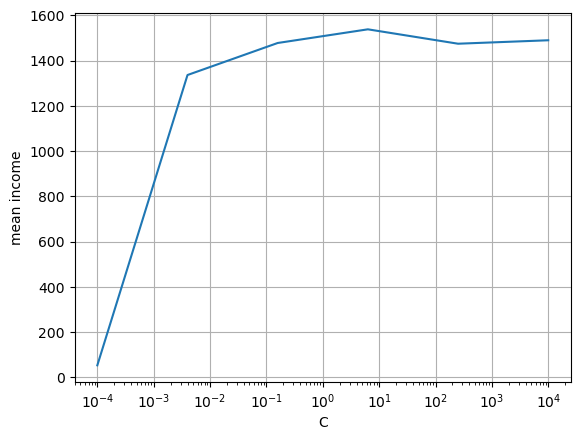

In [641]:
plt.errorbar(x=best_c_dict.values(), y=best_c_dict.keys())
plt.xscale('log')
plt.ylabel('mean income')
plt.xlabel('C')
plt.grid()
plt.show()

Попробуйте запустить перебор несколько раз. Находится ли каждый раз один и тот же "лучший" коэффициент? Присутствует ли какая-то закономерность? Какие вы можете сделать из этого выводы?

In [635]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=True,
    C = 1
):
    metrics = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        numerical_features = X.select_dtypes([np.number]).columns.tolist()
        categorical_features = X.select_dtypes(include=['object']).columns.tolist()
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)
            ]
        )
        
        model = LogisticRegression(C=C)

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        auc_pr = average_precision_score(y_test, y_pred_proba)

        true_positives = (y_pred == 1) & (y_test == 1)
        random_revenue = np.random.uniform(0, 20, size=true_positives.sum())
        revenue = np.sum(random_revenue) 
        cost = np.sum(y_pred) * 2
        profit = revenue - cost

        metrics.append({'AUC-PR': auc_pr, 'Profit': profit})
    
    results_df = pd.DataFrame(metrics)

    return results_df['Profit'].mean()

c_param = np.logspace(-4, 4, 6)
best_c_dict = {}
for c in c_param:
    mean_ = cross_validate(X, y, C=c)
    best_c_dict[mean_] = c
print(best_c_dict[max(best_c_dict.keys())])

for _ in range(10):
    c_param = np.logspace(-4, 4, 6)
    best_c_dict = {}
    for c in c_param:
        mean_ = cross_validate(X, y, C=c)
        best_c_dict[mean_] = c
    print("best_C:", best_c_dict[max(best_c_dict.keys())])
    print("mean_income:", max(best_c_dict.keys()))
    print("-------------------------------")

10000.0
best_C: 0.15848931924611143
mean_income: 1508.0804489840928
-------------------------------
best_C: 10000.0
mean_income: 1552.100641924939
-------------------------------
best_C: 10000.0
mean_income: 1522.472063773086
-------------------------------
best_C: 0.15848931924611143
mean_income: 1532.5404140768555
-------------------------------
best_C: 10000.0
mean_income: 1534.091415390467
-------------------------------
best_C: 10000.0
mean_income: 1527.0416206135392
-------------------------------
best_C: 0.15848931924611143
mean_income: 1519.3055359753694
-------------------------------
best_C: 0.15848931924611143
mean_income: 1511.4108706791571
-------------------------------
best_C: 251.18864315095823
mean_income: 1494.714494939625
-------------------------------
best_C: 0.15848931924611143
mean_income: 1532.1271649724852
-------------------------------


Коэффициент либо явлыяется максимальным в логарифмической сетке, либо в близком минимуме, и прыгает между ними.

#### __Задание 13. Ключевая метрика__ (1 балл)

Выше мы уже описали примерную экономическую модель вашей задачи. Как вы считаете, что для вашего бизнеса важнее — хороший precision или recall модели? Почему?

__Ответ:__ Если смотреть на то что штраф(набрали не тому) не такой большой, то думаю что recall будет важнее, так как приносит больше прибыли



> Вспомним, что на самом деле логистическая регрессия предсказывает нам вероятности положительного класса для объекта. Возможно, путем настройки __порога бинаризации__ этих вероятностей мы сможем получить какой-то выигрыш?

Проверьте ваши рассуждения выше с помощью настройки порога бинаризации на кросс-валидации для максимизации прибыли. Воспользуйтесь сеткой от 0 до 1 с шагом 0.01. Напомним, что снижение порога дает нам более высокий recall и более низкий precision, и наоборот. Добавьте новую ML-метрику в ваш CV-пайплайн, найдите такой порог, при котором бизнес-метрика максимальна, и проверьте, связана ли новая ML метрика с профитом

In [637]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=True,
    C=1,
    p=0
):
    metrics = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        numerical_features = X.select_dtypes([np.number]).columns.tolist()
        categorical_features = X.select_dtypes(include=['object']).columns.tolist()
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)
            ]
        )
        
        model = LogisticRegression(C=C)

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_pred_proba > p).astype(int)
        auc_pr = average_precision_score(y_test, y_pred_proba)

        true_positives = (y_pred == 1) & (y_test == 1)
        random_revenue = np.random.uniform(0, 20, size=true_positives.sum())
        revenue = np.sum(random_revenue) 
        cost = np.sum(y_pred) * 2
        profit = revenue - cost

        metrics.append({'AUC-PR': auc_pr, 'Profit': profit})
    
    results_df = pd.DataFrame(metrics)

    return results_df['Profit'].mean()

p_param = np.linspace(0, 1, 100)
best_p_dict = {}
for c in p_param:
    mean_ = cross_validate(X, y, C=best_c_dict[max(best_c_dict.keys())], p=c)
    best_p_dict[mean_] = c
print(best_p_dict[max(best_p_dict.keys())])

0.18181818181818182


In [652]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=True,
    C=1,
    p=0
):
    metrics = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        numerical_features = X.select_dtypes([np.number]).columns.tolist()
        categorical_features = X.select_dtypes(include=['object']).columns.tolist()
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)
            ]
        )
        
        model = LogisticRegression(C=best_c_log['C'])

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_pred_proba > p).astype(int)
        auc_pr = average_precision_score(y_test, y_pred_proba)

        true_positives = (y_pred == 1) & (y_test == 1)
        random_revenue = np.random.uniform(0, 20, size=true_positives.sum())
        revenue = np.sum(random_revenue) 
        cost = np.sum(y_pred) * 2
        profit = revenue - cost

        metrics.append({'AUC-PR': auc_pr, 'Profit': profit, 'Roc_auc_score': roc_auc_score(y_test, y_pred_proba),
                       'p': p})
    
    results_df = pd.DataFrame(metrics)

    print("Average Profit:", results_df['Profit'].mean())
    print("Std Profot:", results_df['Profit'].std())

    total_cost = len(X) * 2
    print("Cost:", total_cost)
    print("Correlation_AUC-PR:", results_df['Profit'].corr(results_df['AUC-PR']))
    print("Correlation_Roc_auc_score:", results_df['Profit'].corr(results_df['Roc_auc_score']))

    return results_df

cross_validate(X, y, C=best_c_dict[max(best_c_dict.keys())], p=best_p_dict[max(best_p_dict.keys())])

Average Profit: 2783.835268133026
Std Profot: 256.644253140702
Cost: 82376
Correlation_AUC-PR: 0.8760561202020374
Correlation_Roc_auc_score: 0.31961182214607153


,AUC-PR,Profit,Roc_auc_score,p
0,0.462313,2939.646609,0.787106,0.181818
1,0.454936,3006.494446,0.797747,0.181818
2,0.442073,2357.983868,0.789212,0.181818
3,0.452540,2867.270659,0.790488,0.181818
4,0.450751,2747.780758,0.795412,0.181818


Постройте график зависимости прибыли от порога бинаризации. Выделите наилучший порог




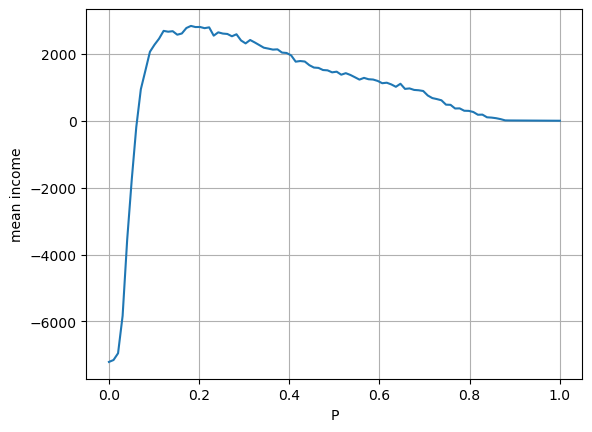

In [648]:
plt.plot(best_p_dict.values(), best_p_dict.keys())
plt.ylabel('mean income')
plt.xlabel('P')
plt.grid()
plt.show()

__Вопрос:__ Замечаете ли вы какую-то закономерность? Для правильного ответа на этот вопрос попробуйте запустить несколько раз и задумайтесь, почему порог получается в какой-то конкретной области?

__Ответ:__ Порог всегда в районе 0.1, значит recall приносит больше прибыли.

Наконец, чтобы точнее понять, что наша модель лучше исходной, посчитайте среднее и стандартное отклонение по фолдам бизнес-метрики для оптимизированной модели (гиперпараметры + порог) и дефолтной логистической регрессии. Проверьте, действительно ли удалось добиться значимого изменения прибыли — примените какой-либо статистический тест (например, парный t-критерий с $\alpha=0.95$) к метрике, полученной двумя этими моделями

In [653]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cross_validate_update(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=True,
    C=1,
    p=0
):
    metrics = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        numerical_features = X.select_dtypes([np.number]).columns.tolist()
        categorical_features = X.select_dtypes(include=['object']).columns.tolist()
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)
            ]
        )
        
        model = LogisticRegression(C=best_c_log['C'])

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_pred_proba > p).astype(int)
        auc_pr = average_precision_score(y_test, y_pred_proba)

        true_positives = (y_pred == 1) & (y_test == 1)
        random_revenue = np.random.uniform(0, 20, size=true_positives.sum())
        revenue = np.sum(random_revenue) 
        cost = np.sum(y_pred) * 2
        profit = revenue - cost

        metrics.append({'AUC-PR': auc_pr, 'Profit': profit, 'Roc_auc_score': roc_auc_score(y_test, y_pred_proba),
                       'p': p})
    
    results_df = pd.DataFrame(metrics)

    return results_df['Profit']


In [660]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cross_validate_default(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=True
):
    metrics = []
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        numerical_features = X.select_dtypes([np.number]).columns.tolist()
        categorical_features = X.select_dtypes(include=['object']).columns.tolist()
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)
            ]
        )
        
        model = LogisticRegression()

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        y_pred = pipeline.predict(X_test)
        auc_pr = average_precision_score(y_test, y_pred_proba)

        true_positives = (y_pred == 1) & (y_test == 1)
        random_revenue = np.random.uniform(0, 20, size=true_positives.sum())
        revenue = np.sum(random_revenue) 
        cost = np.sum(y_pred) * 2
        profit = revenue - cost

        metrics.append({'AUC-PR': auc_pr, 'Profit': profit})
    
    results_df = pd.DataFrame(metrics)

    return results_df['Profit']


In [662]:
from scipy.stats import ttest_rel

profits_optimized = cross_validate_update(X, y, 
                                          C=best_c_dict[max(best_c_dict.keys())], 
                                          p=best_p_dict[max(best_p_dict.keys())])
profits_default = cross_validate_default(X, y)

mean_optimized = np.mean(profits_optimized)
std_optimized = np.std(profits_optimized)
mean_default = np.mean(profits_default)
std_default = np.std(profits_default)

t_stat, p_value = ttest_rel(profits_optimized, profits_default)

print(f"Optimized Model: Mean Profit = {mean_optimized}, Std Dev = {std_optimized}")
print(f"Default Model: Mean Profit = {mean_default}, Std Dev = {std_default}")
print(f"Paired t-test: t-statistic = {t_stat}, p-value = {p_value}")

if p_value < 0.05:
    print("The difference in profits is statistically significant.")
else:
    print("The difference in profits is not statistically significant.")

Optimized Model: Mean Profit = 2758.3129699914625, Std Dev = 243.66559893784316
Default Model: Mean Profit = 1407.6261250815646, Std Dev = 103.0677115725588
Paired t-test: t-statistic = 11.438252519564225, p-value = 0.0003333502419625379
The difference in profits is statistically significant.


# __Бонусная часть. Многоклассовая классификация__ (1.5 балла)

Как известно, некоторые задачи не ограничиваются всего лишь двумя классами. На лекции вы проходили несколько способов обобщения линейных моделей на этот случай: One-vs-Rest и One-vs-One. Ниже мы посмотрим, в чём преимущества и недостатки обоих подходов, а так же попробуем ещё один чуть более экзотический метод

#### **Задание 14. One-vs-Rest vs One-vs-One** (0.5 балла)

В качестве [датасета](https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention/data) здесь и ниже мы будем брать очень жизненные и актуальные данные о том, доучится студент или нет, в зависимости от курсов, возраста, гендера и прочих (не)осуждаемых признаков.

In [6]:
import pandas as pd

features = ["Marital status", "Course", "Nacionality", "Gender", "Age at enrollment"]
target = "Target"
df = pd.read_csv('dataset.csv')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Будем смотреть только какое-то подмножество наиболее весёлых факторов. От вас по классике потребуется их преобразовать, в зависимости от того, числовые они или категориальные и **закодировать таргет чиселками!!!**

In [7]:
X = df[features]
y = (df.Target == 'Graduate')

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=228, shuffle=True, test_size=0.2)

Ваш следующий шаг - посмотреть, каким образом в `sklearn` реализованы OvR и OvO, обучить таким образом логистическую регрессию с `max_iter=10000`, далее выбрать какую-то метрику (и её усреднение, его выбор тоже аргументируйте), и сравнить следующие параметры:
- число классификаторов
- скорость обучения
- качество модели

Также сохраните куда-нибудь предсказания вероятностей у каждой из моделей. Это можно сделать не одним способом, но возможно вам чуть с этим поможет следующий пункт


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import accuracy_score, f1_score, average_precision_score
import numpy as np
import time

begin = time.time()
ovr_model = LogisticRegression(max_iter=10000, multi_class='ovr')
ovr_model.fit(X_train, y_train)
ovr_predictions = ovr_model.predict(X_test)
print("time_ovr:", time.time() - begin)
ovr_probabilities = ovr_model.predict_proba(X_test)

begin = time.time()
ovo_model = OneVsOneClassifier(LogisticRegression(max_iter=10000))
ovo_model.fit(X_train, y_train)
ovo_predictions = ovo_model.predict(X_test)
print("time_ovo:", time.time() - begin)
ovo_probabilities = ovo_model.decision_function(X_test)


ovr_accuracy = accuracy_score(y_test, ovr_predictions)
ovo_accuracy = accuracy_score(y_test, ovo_predictions)

ovr_f1 = f1_score(y_test, ovr_predictions, average='macro')
ovo_f1 = f1_score(y_test, ovo_predictions, average='macro')

auc_pr_ovr = average_precision_score(y_test, ovr_probabilities[:, 1])
auc_pr_ovo = average_precision_score(y_test, ovo_probabilities)

print(f"OvR Accuracy: {ovr_accuracy}, F1 Score: {ovr_f1}, AUC-PR: {auc_pr_ovr}")
print(f"OvO Accuracy: {ovo_accuracy}, F1 Score: {ovo_f1}, AUC-PR: {auc_pr_ovo}")


time_ovr: 0.10188126564025879
time_ovo: 0.05007505416870117
OvR Accuracy: 0.615819209039548, F1 Score: 0.6148233486943164, AUC-PR: 0.6123511156438143
OvO Accuracy: 0.615819209039548, F1 Score: 0.6148233486943164, AUC-PR: 0.6123511156438143


In [17]:
ovr_probabilities, ovo_probabilities

(array([[0.63436229, 0.36563771],
        [0.60076596, 0.39923404],
        [0.69025238, 0.30974762],
        ...,
        [0.39223372, 0.60776628],
        [0.39679168, 0.60320832],
        [0.59789091, 0.40210909]]),
 array([-0.11841507, -0.09670143, -0.14828174,  1.11812463, -0.11129394,
         1.03381454, -0.09036299, -0.1415709 ,  1.11812463, -0.09163291,
         1.1044438 ,  1.10948402,  1.11115004, -0.05005752,  1.10023589,
        -0.06647129, -0.10622642, -0.11235497,  1.11066762, -0.18156843,
         1.03433387,  1.06227299,  1.11007739,  1.11554101,  1.07858961,
        -0.088953  ,  1.11912153,  1.10140495, -0.16804695,  1.11600257,
         1.09408784,  1.09146239, -0.01306253,  1.12423651,  1.10839518,
         1.10140495, -0.10622642, -0.09357409, -0.07344101,  1.12064767,
        -0.09220123, -0.02806914, -0.12657482,  1.11757332, -0.18745437,
        -0.01060813,  1.1061854 , -0.09670143,  1.12268041, -0.02566697,
         1.0038852 ,  1.02244328,  1.07924067, -0.1

Как вы объясните полученные результаты?

__Ответ:__ Одинаковые результаты указывают на то, что для данной задачи и данных обе стратегии являются равноценными.

#### __Задание 15. Softmax регрессия__ (1 балл)

Однако любознательные машинисты могут задаться вопросом "А зачем нам вся эта шляпа, если у сигмоиды есть обобщение на случай многоклассовой классификации?" Если вам понравилось считать градиенты в прошлом дз, или вам нравится обучать нейросети, этот пункт для вас. Здесь мы попробуем построить одну-единственную модель, которая будет всё предсказывать, а также сравним с вариантами выше

Начнём с подсчёта лосса. Вспомним, что логистическая функция потерь это частный случай кросс-энтропии, её и будем пытаться оптимизировать.

$$
\text{CE}(X, y) = -\frac{1}{N}\sum_i \sum_k [y_i = k] \log p(x_i = k)
$$
Вероятности в данном случае будем считать при помощи софтмакса, что есть общий случай сигмоиды

$$
p(x_i) = \text{Softmax}(a(x_i)); \quad
\text{Softmax}(x)_k = \frac{e^{x_{k}}}{\sum_j e^{x_{j}}} \\
$$

Предсказание модели на одном объекта будет делаться уже при помощи матрицы весов, посклоьку выходов несколько

$$
a(x_i) = x_i\cdot W \\
$$

Ниже предлагается написать код для такой функции потерь. Если необходимо, модифицируйте шаблон по своему усмотрению (вспомогательные функции, новые аргументы, всё, что душа пожелает)

In [21]:
from typing import Iterable, Optional
from torch.nn.functional import cross_entropy
import torch

def custom_ce(
    y_pred: np.ndarray[float],
    y_true: np.ndarray[int],
) -> float:
    
    y_pred_tensor = torch.tensor(y_pred, dtype=torch.float32)
    y_true_tensor = torch.tensor(y_true, dtype=torch.int64)
    softmax_pred = torch.softmax(y_pred_tensor, dim=1)
    log_softmax_pred = torch.log(softmax_pred)
    loss = -torch.mean(torch.sum(torch.nn.functional.one_hot(y_true_tensor, num_classes=y_pred_tensor.size(1)) * log_softmax_pred, dim=1))

    return loss.item()

In [22]:
for _ in range(1000):

    n_objects = np.random.randint(1, 100)
    n_classes = np.random.randint(2, 20)
    y_pred = np.random.normal(0, 1, (n_objects, n_classes))
    y_true = np.random.randint(low=0, high=n_classes, size=(n_objects,))

    your_ce = custom_ce(y_pred, y_true) # не забудьте поправить, если меняли шаблон
    torch_ce = cross_entropy(torch.tensor(y_pred), torch.tensor(y_true))
    assert np.allclose(your_ce, torch_ce), "Что-то пошло не так"

Дальше самая интересная часть - нужно вывести производную этой функции потерь (на всякий случай уточним, что `torch` использовать нельзя, разве что для самопроверки). Полезные факты, которые вам могут пригодиться:

- в матричном виде найти производную непросто, попробуйте сперва сделать это для одного объекта, обобщить будет полегче
- логсофтмакс дифференцировать гораздо легче, чем просто софтмакс
- не забывайте про правило дифференцирования сложной функции
- поскольку веса в данном случае матрица, результат будет тоже матрица, учтите при сверке размерностей
- если вы не придумали, как преобразовать индикаторы в векторный вид, сейчас самое время

In [40]:
#Данный класс взято из моего дз по курсу ДЛ
def compute_grad_input(self, input: np.ndarray, grad_output: np.ndarray) -> np.ndarray:
        """
        :param input: array of size (batch_size, num_classes)
        :param grad_output: array of the same size
        :return: array of the same size
        """
        sm = softmax(input, axis=1)
        diag = np.expand_dims(sm, axis=-1) * np.expand_dims(np.eye(input.shape[1], input.shape[1]), axis=0)
        not_diag = np.einsum('ij,ik->ijk', sm, sm)
        return np.einsum('ijk,ik->ij', diag - not_diag, grad_output / sm)

    
#Данный класс взято из моего дз по курсу ДЛ
class CrossEntropyLoss:
    """
    Cross-entropy criterion over distribution logits
    """
    def __init__(self):
        self.log_softmax = LogSoftmax()
    
    def compute_output(self, input: np.ndarray, target: np.ndarray) -> float:
        """
        :param input: logits array of size (batch_size, num_classes)
        :param target: labels array of size (batch_size, )
        :return: loss value
        """
        log_probs = self.log_softmax.compute_output(input)
        batch_size = input.shape[0]
        loss = -np.sum(log_probs[np.arange(batch_size), target]) / batch_size
        return loss
    
    def compute_grad_input(self, input: np.ndarray, target: np.ndarray) -> np.ndarray:
        """
        :param input: logits array of size (batch_size, num_classes)
        :param target: labels array of size (batch_size, )
        :return: gradient array of size (batch_size, num_classes)
        """
        batch_size = input.shape[0]
        probs = np.exp(self.log_softmax.compute_output(input))
        probs[np.arange(batch_size), target] -= 1
        grad_input = probs / batch_size
        return grad_input

Дальше дело за малым. Вспомните (или узнайте), как делается градиентный спуск, и дополните класс софтмакс-регрессии ниже. Здесь разумнее использовать критерий останова по итерациям, но логрег из `sklearn` устроен немного хитрее. Если хотите добавить еще критерии останова, какие-то другие параметры, то пожалуйста

Обучите на тех же данных, что и выше, замерьте те же три параметра, плюс сравните значения кросс-энтропии для уже трёх моделей. Сравните модели между собой и выберите фаворита в данной задаче.

In [49]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


#Данный класс взято из моего дз по курсу ДЛ
def compute_grad_input(self, input: np.ndarray, grad_output: np.ndarray) -> np.ndarray:
        """
        :param input: array of size (batch_size, num_classes)
        :param grad_output: array of the same size
        :return: array of the same size
        """
        sm = softmax(input, axis=1)
        diag = np.expand_dims(sm, axis=-1) * np.expand_dims(np.eye(input.shape[1], input.shape[1]), axis=0)
        not_diag = np.einsum('ij,ik->ijk', sm, sm)
        return np.einsum('ijk,ik->ij', diag - not_diag, grad_output / sm)

    
#Данный класс взято из моего дз по курсу ДЛ
class CrossEntropyLoss:
    """
    Cross-entropy criterion over distribution logits
    """
    def __init__(self):
        self.log_softmax = LogSoftmax()
    
    def compute_output(self, input: np.ndarray, target: np.ndarray) -> float:
        """
        :param input: logits array of size (batch_size, num_classes)
        :param target: labels array of size (batch_size, )
        :return: loss value
        """
        log_probs = self.log_softmax.compute_output(input)
        batch_size = input.shape[0]
        loss = -np.sum(log_probs[np.arange(batch_size), target]) / batch_size
        return loss
    
    def compute_grad_input(self, input: np.ndarray, target: np.ndarray) -> np.ndarray:
        """
        :param input: logits array of size (batch_size, num_classes)
        :param target: labels array of size (batch_size, )
        :return: gradient array of size (batch_size, num_classes)
        """
        batch_size = input.shape[0]
        probs = np.exp(self.log_softmax.compute_output(input))
        probs[np.arange(batch_size), target] -= 1
        grad_input = probs / batch_size
        return grad_input

class SoftmaxRegression:
    def __init__(self, lr=1e-3, max_iter=10000):
        self.W = None
        self.max_iter = max_iter
        self.lr = lr
        self.criterion = CrossEntropyLoss()
    
    def fit(self, X: np.ndarray, y: np.ndarray):
        num_samples, num_features = X.shape
        self.label_encoder = LabelEncoder()
        y_encoded = self.label_encoder.fit_transform(y)
        num_classes = len(np.unique(y_encoded))
        self.W = np.zeros((num_features, num_classes))
        
        for i in range(1, self.max_iter + 1):
            logits = np.dot(X, self.W)
            loss = self.criterion.compute_output(logits, y_encoded)
            grad_logits = self.criterion.compute_grad_input(logits, y_encoded)
            grad_W = np.dot(X.T, grad_logits)
            
            self.W -= self.lr * grad_W
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        logits = np.dot(X, self.W)
        softmax_pred = self.softmax(logits)
        return np.argmax(softmax_pred, axis=1)
    
    def evaluate(self, X: np.ndarray, y: np.ndarray) -> float:
        logits = np.dot(X, self.W)
        predictions = np.argmax(softmax(logits), axis=1)
        y_encoded = self.label_encoder.transform(y)
        accuracy = accuracy_score(y_encoded, predictions)
        return accuracy

begin = time.time()
softmax_model = SoftmaxRegression(lr=0.01, max_iter=1000)
softmax_model.fit(X_train, y_train)
print("time:", time.time() - begin)
accuracy = softmax_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy}")

time: 0.3460259437561035
Test Accuracy: 0.49830508474576274


__Ответ__: Стало немного хуже, думаю из за того что W у нас пустое.

__Бонус (0.01 балла):__ что вы кушали в день сдачи данного ДЗ на завтрак?

__Ответ:__ Вкусно и точка)